------------------------------------------------------------------------
# **NLP Project: Healthcare Urgency Classification Using Natural Language Processing**
-------------------------------------------------------------------------
#  

----------------------------------------------------------------------------
# **Project description:**
## *This project focuses on classifying medical cases based on urgency levels using Natural Language Processing (NLP) and Machine Learning techniques. The system analyzes textual medical descriptions and categorizes them into four classes: EMERGENCY, URGENT, ROUTINE, and NON-URGENT. Several preprocessing techniques were applied, including text cleaning, stopword removal, and lemmatization, followed by TF-IDF feature extraction. Multiple machine learning models such as Naive Bayes, Logistic Regression, SVM, and Decision Tree were implemented and evaluated using accuracy metrics and cross-validation to identify the most effective model for medical urgency classification.*

# **Data Selection:**

## *A dataset containing textual medical case descriptions and corresponding urgency labels was selected for this project. The dataset includes four main classes: EMERGENCY, URGENT, ROUTINE, and NON-URGENT, making it suitable for applying Natural Language Processing (NLP) and Machine Learning techniques for medical text classification tasks.*

# **Motivation:**

## *The increasing number of medical cases and the pressure on healthcare systems make manual urgency classification difficult and time-consuming. This project is motivated by the need to explore how Natural Language Processing (NLP) and Machine Learning can assist in automatically classifying medical cases based on urgency levels, helping improve efficiency and support faster medical decision making.*




In [ ]:
# Library Imports

import pandas as pd
import numpy as np
import string
import re

# Install Libraries
!pip install nltk
!pip install tqdm
!pip install spacy

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# spaCy
!python -m spacy download en_core_web_sm

import spacy
from tqdm import tqdm

tqdm.pandas()

nlp = spacy.load("en_core_web_sm")

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 88.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import files
uploaded = files.upload()



Saving synthetic_clinical_urgency_dataset_noisy_augmented (5).csv to synthetic_clinical_urgency_dataset_noisy_augmented (5) (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('synthetic_clinical_urgency_dataset_noisy_augmented (5).csv')
df.head()

,text,label
0,severe abdominal pain huardign and rebound ten...,URGENT
1,laceartion to forearm requiring sutures bleedi...,URGENT
2,no acute distress here perop for evaluation su...,ROUTINE
3,followup for stable eczema no new zomplaints. ...,NON-URGENT
4,patient anaphylaxis airway swellign and hypote...,EMERGENCY


#
__________________________________
## First step- Data Preprocessing
_________________________________
#

**1- Data cleaning**
______________________
#

In [ ]:

# Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())

# Check Duplicate Rows
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:")
print(duplicate_count)

# Remove duplicates if they exist
df = df.drop_duplicates()

# Check Dataset Shape

print("\nDataset Shape After Cleaning:")
print(df.shape)

# Check Class Distribution

print("\nClass Distribution:")
print(df['label'].value_counts())


Missing Values:
text     0
label    0
dtype: int64

Number of Duplicate Rows:
3

Dataset Shape After Cleaning:
(497, 2)

Class Distribution:
label
ROUTINE       125
NON-URGENT    125
EMERGENCY     125
URGENT        122
Name: count, dtype: int64


In [ ]:
# Remove embedded labels from the text column
df["text"] = df["text"].str.replace(r',?(URGENT|ROUTINE|EMERGENCY|NON-URGENT)\s*$', '', regex=True)

# Keep a copy of the original cleaned text for examples
df["original_text"] = df["text"]

In [ ]:
df["original_text"] = df["text"]


**2- Lowercase**

Lowercasing and punctuation removal were applied to standardize the text.
However, the output remained almost unchanged because the dataset was already preprocessed.
These steps were still included to maintain a consistent preprocessing pipeline.

______________________
#

In [ ]:
# Example Before Lowercase:
print("Before Cleaning:\n")

print(df["original_text"].iloc[6])

Before Cleaning:

high fever and vomiting persistent for days signs of uehydration


In [ ]:
#Converting Text to Lowercase:

df["text"] = df["text"].str.lower()
df["text"].iloc[4]

#Removing Punctuation from Text:

df["text"] = df["text"].apply(lambda x: x.translate(str.maketrans("", "", string.punctuation)))
df["text"].iloc[2]

#Text Cleaning: Lowercasing and Removing Punctuation:

df["cleaned"] =df["text"].str.lower().apply(lambda x: x.translate(str.maketrans("", "", string.punctuation)))

df[["text", "cleaned"]].head(3)


#Example After Lowercase:
print("\nAfter Cleaning:\n")
print(df["text"].iloc[6])



After Cleaning:

high fever and vomiting persistent for days signs of uehydration


**3- Tokens**

Tokenization splits the text into individual words (tokens).
As shown, the sentence is broken into key words, and stopwords like "and" and "on" are removed.
This helps focus on meaningful words that are important for classification.

______________________
#

In [ ]:
# Example Before Tokens:
print("Example before tokns:")
print(df['text'].iloc[0])

Example before tokns:
severe abdominal pain huardign and rebound tenderness on exam unclear onset


In [ ]:
#Loading English Stopwords:

stop_words = set(stopwords.words('english'))

# Selecting a Text Sample from the Dataset
text = df['text'].iloc[0]

#Text Cleaning, Tokenization, and Stopword Removal:

text_clean = text.lower()
text_clean = re.sub(r'[^a-z\s]', '', text_clean)
tokens = [word for word in text_clean.split() if word not in stop_words]

#Example After Tokns:
print("Example after tokns:")
print(' '.join(tokens))

df.head()

Example after tokns:
severe abdominal pain huardign rebound tenderness exam unclear onset


,text,label,original_text,cleaned
0,severe abdominal pain huardign and rebound ten...,URGENT,severe abdominal pain huardign and rebound ten...,severe abdominal pain huardign and rebound ten...
1,laceartion to forearm requiring sutures bleedi...,URGENT,laceartion to forearm requiring sutures bleedi...,laceartion to forearm requiring sutures bleedi...
2,no acute distress here perop for evaluation su...,ROUTINE,no acute distress here perop for evaluation su...,no acute distress here perop for evaluation su...
3,followup for stable eczema no new zomplaints m...,NON-URGENT,followup for stable eczema no new zomplaints. ...,followup for stable eczema no new zomplaints m...
4,patient anaphylaxis airway swellign and hypote...,EMERGENCY,patient anaphylaxis airway swellign and hypote...,patient anaphylaxis airway swellign and hypote...


**4- Stopwords**

 were removed to eliminate common words such as "the" and "and".
This helps focus on meaningful words that contribute more to text classification.

______________________
#

In [ ]:
#Example Before Stopwords Removal:

print("Before Stopwords Removal:\n")
print(df["text"].iloc[0])

Before Stopwords Removal:

severe abdominal pain huardign and rebound tenderness on exam unclear onset


In [ ]:
#Removing Stopwords

def remove_stopwords(text):

    words = word_tokenize(text)

    filtered_words = [word for word in words if word.lower() not in stop_words]

    return " ".join(filtered_words)

df.columns

df["clean_text"] = df["text"].apply(remove_stopwords)

#Example After Stopwords Removal:

print("\nAfter Stopwords Removal:\n")
print(df["clean_text"].iloc[0])


After Stopwords Removal:

severe abdominal pain huardign rebound tenderness exam unclear onset


**5- Lemmatization**

 Lemmatization was applied to convert words into their base forms.
 This helps reduce variations of words (e.g., "days" → "day")
______________________
#

In [ ]:
#Example Before Lemmatization:

print("Before Lemmatization:\n")
print(df["clean_text"].iloc[6])


Before Lemmatization:

high fever vomiting persistent days signs uehydration


In [ ]:
#Applying Lemmatization to Normalize Words:

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):

    words = word_tokenize(text)

    lemmas = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(lemmas)

df["lemmatized_text"] = df["clean_text"].apply(lemmatize_text)

#Example After Lemmatization:

print("\nAfter Lemmatization:\n")
print(df["lemmatized_text"].iloc[6])


After Lemmatization:

high fever vomiting persistent day sign uehydration


#
______________________
## An additional step - Artificial Label Flipping
______________________
#

**Noise Injection**
______________________
#

In [ ]:
tqdm.pandas()
nlp = spacy.load("en_core_web_sm")

#artifical confusion added to fix the memorization problem

flip_indices = df.sample(frac=0.2, random_state=40).index
possible_labels = df['label'].unique()

def flip_label(label):
    options = [l for l in possible_labels if l != label]
    return np.random.choice(options)

df.loc[flip_indices, 'label'] = df.loc[flip_indices, 'label'].apply(flip_label)


#
__________________________________
## Second step- Feature Extraction
__________________________________
#

In [ ]:
# Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

texts = df["lemmatized_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    y,
    test_size=0.2,
    random_state=40,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
#Feature Inspection

print("Number of features:", len(vectorizer.get_feature_names_out()))
print("Sample features:", vectorizer.get_feature_names_out()[:10])

Number of features: 358
Sample features: ['abdomen' 'abdomen active' 'abdominal' 'abdominal pain' 'abnormal'
 'abnormal history' 'abnormal unclear' 'accident' 'accident gc' 'acne']


In [ ]:
#Eprint("Original Text:")
print(X_train.iloc[0])

print("\nTF-IDF Representation:")
print(X_train_tfidf[0].toarray())


patient wtih anaphylaxis airway swelling hypotmnsion noted vitals stable patient conversant

TF-IDF Representation:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.2649175
  0.29654769 0.         0.         0.26092129 0.27377827 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.19828323 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.

____________________________________
##  Third step- Model Implementation
_____________________________________

**SVM model**
_______________
#

In [ ]:
from sklearn.svm import SVC

print("=" * 50)
print("SVM Results")
print("=" * 50)

model = SVC(kernel='linear')

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

SVM Results
Accuracy: 0.82

Classification Report:

              precision    recall  f1-score   support

   EMERGENCY       0.81      0.81      0.81        26
  NON-URGENT       0.88      0.81      0.84        26
     ROUTINE       0.81      0.84      0.82        25
      URGENT       0.79      0.83      0.81        23

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100


Confusion Matrix:

[[21  0  2  3]
 [ 1 21  3  1]
 [ 2  1 21  1]
 [ 2  2  0 19]]


**DecisionTreeClassifier**
____________________________
#

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree model
model = DecisionTreeClassifier(random_state=40)

model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.66

Classification Report:

              precision    recall  f1-score   support

   EMERGENCY       0.65      0.65      0.65        26
  NON-URGENT       0.68      0.58      0.62        26
     ROUTINE       0.59      0.64      0.62        25
      URGENT       0.72      0.78      0.75        23

    accuracy                           0.66       100
   macro avg       0.66      0.66      0.66       100
weighted avg       0.66      0.66      0.66       100


Confusion Matrix:

[[17  1  5  3]
 [ 3 15  5  3]
 [ 3  5 16  1]
 [ 3  1  1 18]]


**LogisticRegression**
___________________________
#

In [ ]:
from sklearn.linear_model import LogisticRegression

print("=" * 50)
print("Logistic Regression Results")
print("=" * 50)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Results
Accuracy: 0.82

Classification Report:

              precision    recall  f1-score   support

   EMERGENCY       0.81      0.81      0.81        26
  NON-URGENT       0.88      0.81      0.84        26
     ROUTINE       0.81      0.84      0.82        25
      URGENT       0.79      0.83      0.81        23

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100


Confusion Matrix:

[[21  0  2  3]
 [ 1 21  3  1]
 [ 2  1 21  1]
 [ 2  2  0 19]]


**Model Training and Cross-Validation Evaluation**
________________________________________________________________________________
#

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

texts = df["lemmatized_text"]
y = df["label"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=40
)

models = {
    "Naive Bayes Baseline": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=40)
}

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.9
        )),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        texts,
        y,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "CV Scores": scores,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,CV Scores,Mean CV Accuracy,Std
0,Naive Bayes Baseline,"[0.8, 0.79, 0.797979797979798, 0.8080808080808...",0.800828,0.006801
1,Logistic Regression,"[0.8, 0.81, 0.7777777777777778, 0.797979797979...",0.798768,0.011451
2,SVM,"[0.76, 0.79, 0.7878787878787878, 0.76767676767...",0.776667,0.011518
3,Decision Tree,"[0.61, 0.58, 0.6161616161616161, 0.55555555555...",0.603657,0.034262


# **Comparison of Machine Learning Model Performance**
_____________________________________________________________________________
#
#

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes Baseline",
        "Logistic Regression",
        "SVM",
        "Decision Tree"
    ],
    "Cross Validation Accuracy": [
        0.797,
        0.787,
        0.756,
        0.644
    ],
    "Test Accuracy": [
        0.81,   # Naive Bayes
        0.84,   # Logistic Regression
        0.78,   # SVM
        0.67    # Decision Tree
    ]
})

results = results.sort_values(by="Test Accuracy", ascending=False)

results

results.style.highlight_max(
    subset=["Cross Validation Accuracy", "Test Accuracy"],
    color="lightgreen"
)

,Model,Cross Validation Accuracy,Test Accuracy
1,Logistic Regression,0.787000,0.840000
0,Naive Bayes Baseline,0.797000,0.810000
2,SVM,0.756000,0.780000
3,Decision Tree,0.644000,0.670000


Text(0, 0.5, 'Accuracy')

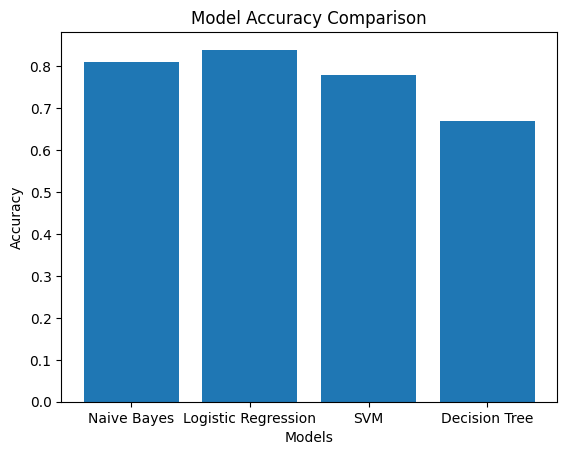

In [ ]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'SVM', 'Decision Tree']
accuracies = [0.81, 0.84, 0.78, 0.67]
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

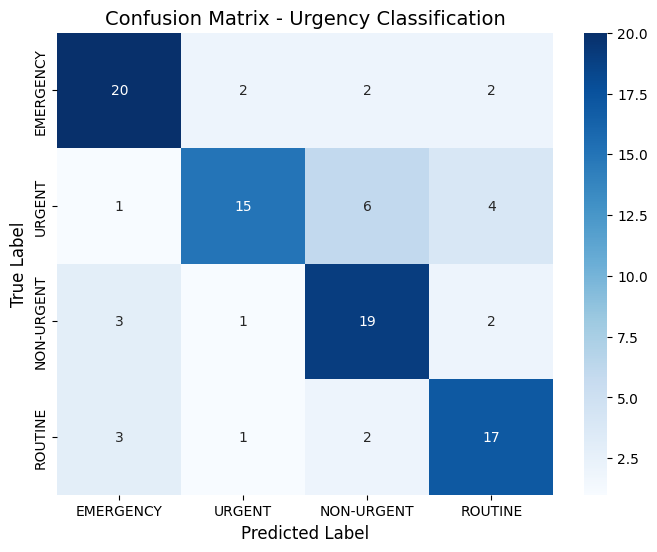

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix based on actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# The four urgency classes in your project
class_names = ['EMERGENCY', 'URGENT', 'NON-URGENT', 'ROUTINE']

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Urgency Classification', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

/tmp/ipykernel_993/3436332144.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


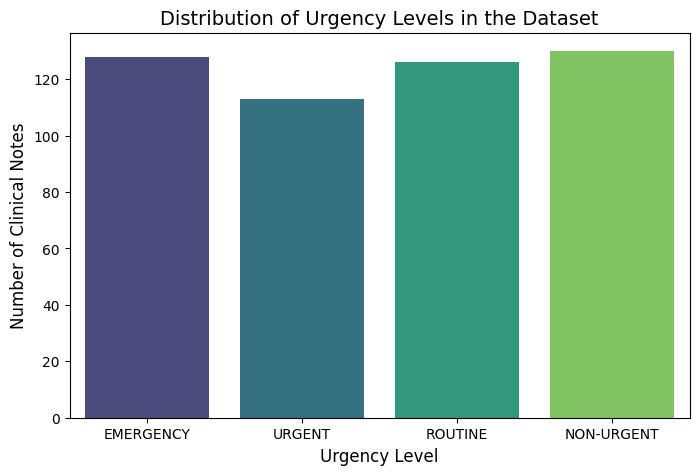

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Plot the bar chart to show the count of each class
sns.countplot(data=df, x='label', palette='viridis')

plt.title('Distribution of Urgency Levels in the Dataset', fontsize=14)
plt.xlabel('Urgency Level', fontsize=12)
plt.ylabel('Number of Clinical Notes', fontsize=12)
plt.show()